Import statements

In [1]:
import pandas as pd
import yfinance as yf

Moon data

In [2]:
df_moon = pd.read_csv('~/ai-price-predictor/data/moon_phases_UTC_1800-2050.csv')
df_moon = df_moon[['Date', 'Category', 'Phase']]
print(df_moon)
mask = (df_moon["Date"] >= "2003-08-05") & (df_moon["Date"] <= "2025-12-30")
df_moon = df_moon.loc[mask]
# df_moon.head()

             Date  Category   Phase
0      1800-01-01         1  0.1822
1      1800-01-02         2  0.2161
2      1800-01-03         2  0.2499
3      1800-01-04         3  0.2838
4      1800-01-05         3  0.3177
...           ...       ...     ...
91307  2049-12-28         1  0.1105
91308  2049-12-29         1  0.1445
91309  2049-12-30         1  0.1784
91310  2049-12-31         2  0.2123
91311  2050-01-01         2  0.2463

[91312 rows x 3 columns]


In [3]:
df_moon["Date"] = pd.to_datetime(df_moon["Date"])


In [4]:
df_moon.head()

,Date,Category,Phase
74360,2003-08-05,2,0.2280
74361,2003-08-06,2,0.2620
74362,2003-08-07,3,0.2960
74363,2003-08-08,3,0.3299
74364,2003-08-09,3,0.3639


Extract EUR GBP OHLC

In [5]:
df_eurgbp = yf.download(
    "EURGBP=X",
    start="2003-08-05",
    end="2025-12-30",
    interval="1d"
)

[*********************100%***********************]  1 of 1 completed


In [6]:
df_eurgbp.head()

Price,Close,High,Low,Open,Volume
Ticker,EURGBP=X,EURGBP=X,EURGBP=X,EURGBP=X,EURGBP=X
Date,,,,,
2003-08-05,0.7055,0.7078,0.7023,0.7042,0
2003-08-06,0.7041,0.7078,0.7030,0.7056,0
2003-08-07,0.7032,0.7077,0.7019,0.7041,0
2003-08-08,0.7042,0.7056,0.7016,0.7033,0
2003-08-11,0.7065,0.7071,0.7032,0.7054,0


In [7]:
df_eurgbp.index = pd.to_datetime(df_eurgbp.index)

In [8]:
df_eurgbp.columns = df_eurgbp.columns.get_level_values(0)

In [9]:
df_eurgbp = df_eurgbp.drop(columns=['Volume'])

In [10]:
df_eurgbp

Price,Close,High,Low,Open
Date,,,,
2003-08-05,0.70550,0.70780,0.70230,0.70420
2003-08-06,0.70410,0.70780,0.70300,0.70560
2003-08-07,0.70320,0.70770,0.70190,0.70410
2003-08-08,0.70420,0.70560,0.70160,0.70330
2003-08-11,0.70650,0.70710,0.70320,0.70540
...,...,...,...,...
2025-12-22,0.87513,0.87530,0.87276,0.87518
2025-12-23,0.87343,0.87367,0.87200,0.87339
2025-12-24,0.87281,0.87308,0.87187,0.87278


In [11]:
df_moon.set_index('Date', inplace=True)

In [12]:
df_moon

,Category,Phase
Date,,
2003-08-05,2,0.2280
2003-08-06,2,0.2620
2003-08-07,3,0.2960
2003-08-08,3,0.3299
2003-08-09,3,0.3639
...,...,...
2025-12-26,2,0.1992
2025-12-27,2,0.2328
2025-12-28,3,0.2664


In [ ]:
df_merged = df_eurgbp.join(df_moon, how="inner")


KeyError: Index(['Date'], dtype='object')

In [15]:
df_merged

,Close,High,Low,Open,Category,Phase
Date,,,,,,
2003-08-05,0.70550,0.70780,0.70230,0.70420,2,0.2280
2003-08-06,0.70410,0.70780,0.70300,0.70560,2,0.2620
2003-08-07,0.70320,0.70770,0.70190,0.70410,3,0.2960
2003-08-08,0.70420,0.70560,0.70160,0.70330,3,0.3299
2003-08-11,0.70650,0.70710,0.70320,0.70540,3,0.4318
...,...,...,...,...,...,...
2025-12-22,0.87513,0.87530,0.87276,0.87518,1,0.0648
2025-12-23,0.87343,0.87367,0.87200,0.87339,1,0.0984
2025-12-24,0.87281,0.87308,0.87187,0.87278,1,0.1320


In [16]:
df_merged.to_csv('~/ai-price-predictor/data/eurgbp_moon_phases.csv') # Save the merged DataFrame to a CSV file

Plot price over time

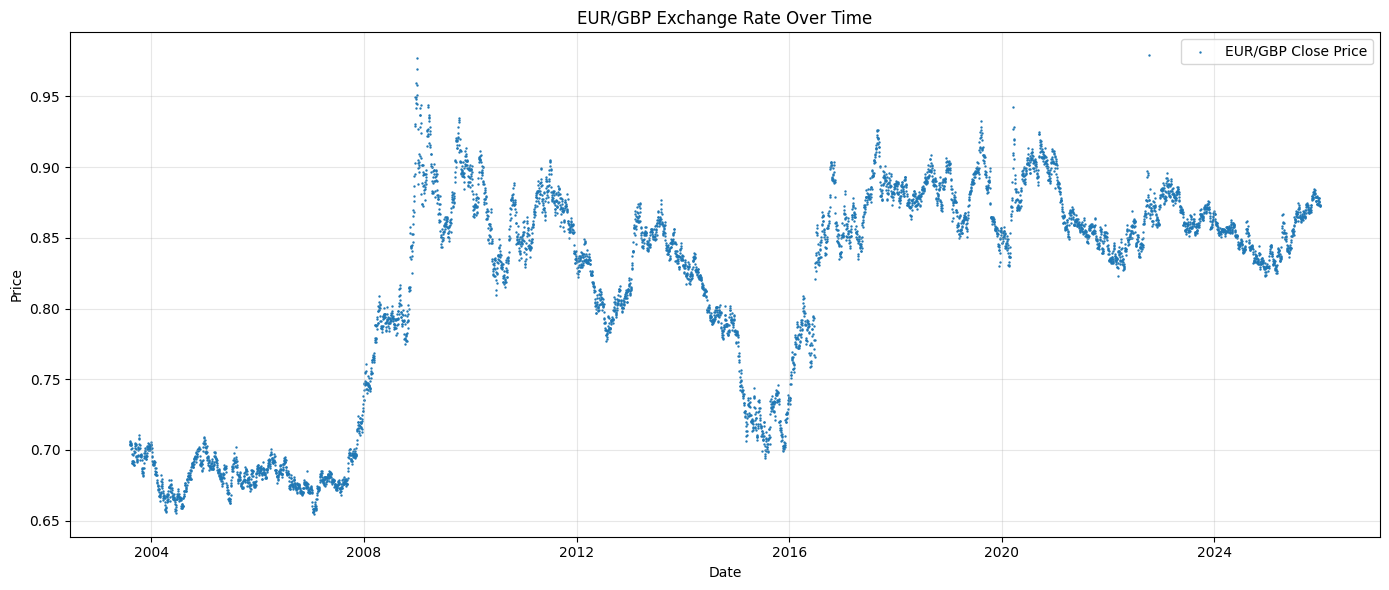

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.scatter(df_merged.index, df_merged['Close'], label='EUR/GBP Close Price', s=0.5)
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('EUR/GBP Exchange Rate Over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Plot phase over time

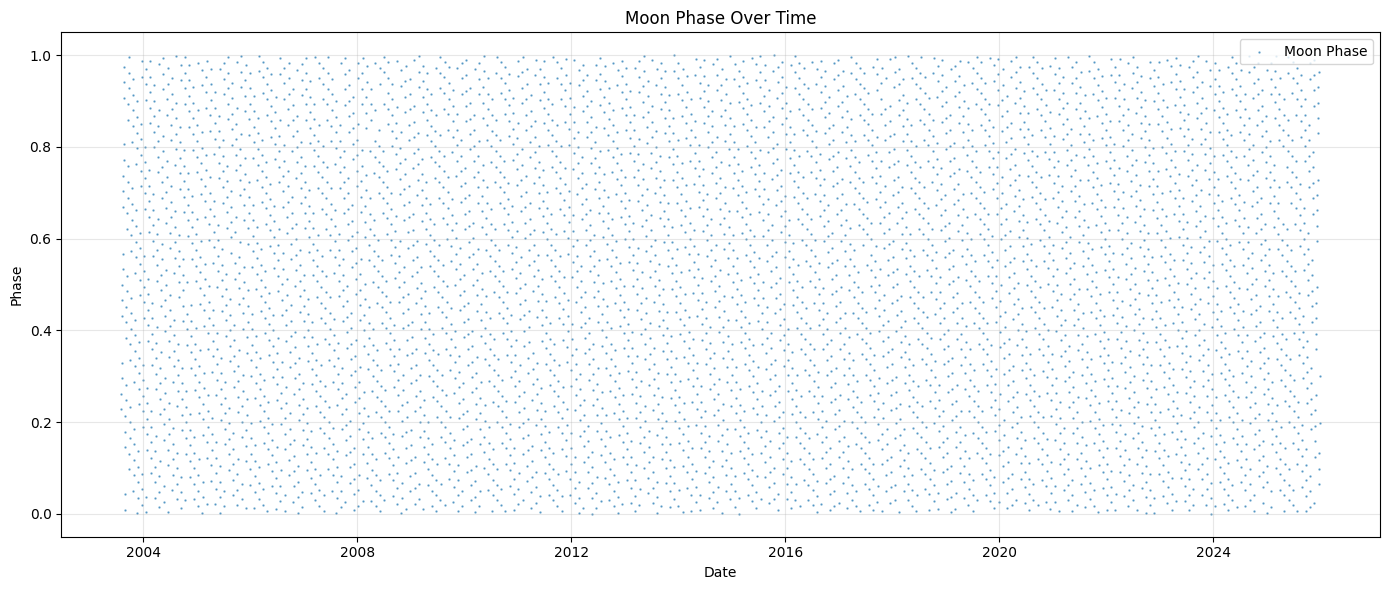

In [23]:
plt.figure(figsize=(14, 6))
plt.scatter(df_merged.index, df_merged['Phase'], label='Moon Phase', s=0.5, alpha=0.6)
plt.xlabel('Date')
plt.ylabel('Phase')
plt.title('Moon Phase Over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()